
STATISTICAL ARBITRAGE BASELINE ANALYSIS
Loading data for 4 tickers...
Downloaded data shape: (752, 20)
Loaded 752 days of data
Date range: 2022-01-03 to 2024-12-30
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'MSFT']

Correlation Matrix:
Ticker      AAPL      AMZN     GOOGL      MSFT
Ticker                                        
AAPL    1.000000  0.565609  0.623614  0.685326
AMZN    0.565609  1.000000  0.652217  0.691262
GOOGL   0.623614  0.652217  1.000000  0.694316
MSFT    0.685326  0.691262  0.694316  1.000000

Most correlated pair: GOOGL & MSFT
Correlation: 0.6943

Backtesting pair: GOOGL vs MSFT

Performance Summary:
------------------------------------------------------------
Total Return:            28.08%
Annualized Return:        8.65%
Sharpe Ratio:              0.69
Max Drawdown:            -9.37%
Win Rate:                55.63%
Number of Trades:            64
------------------------------------------------------------


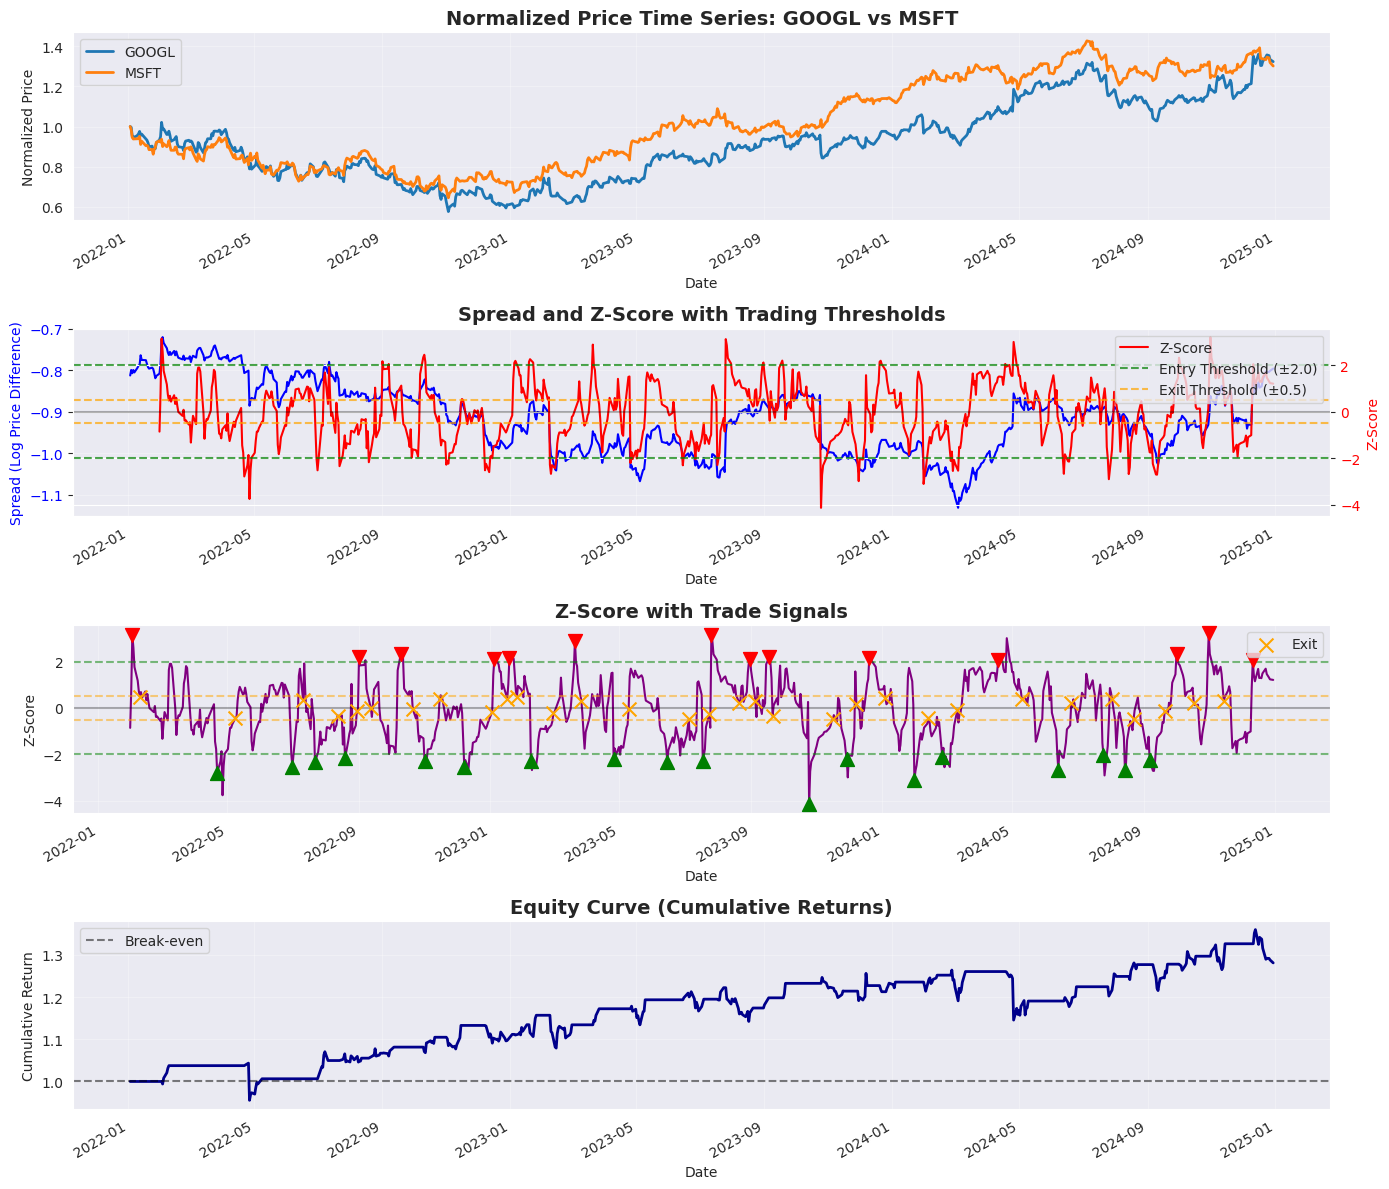

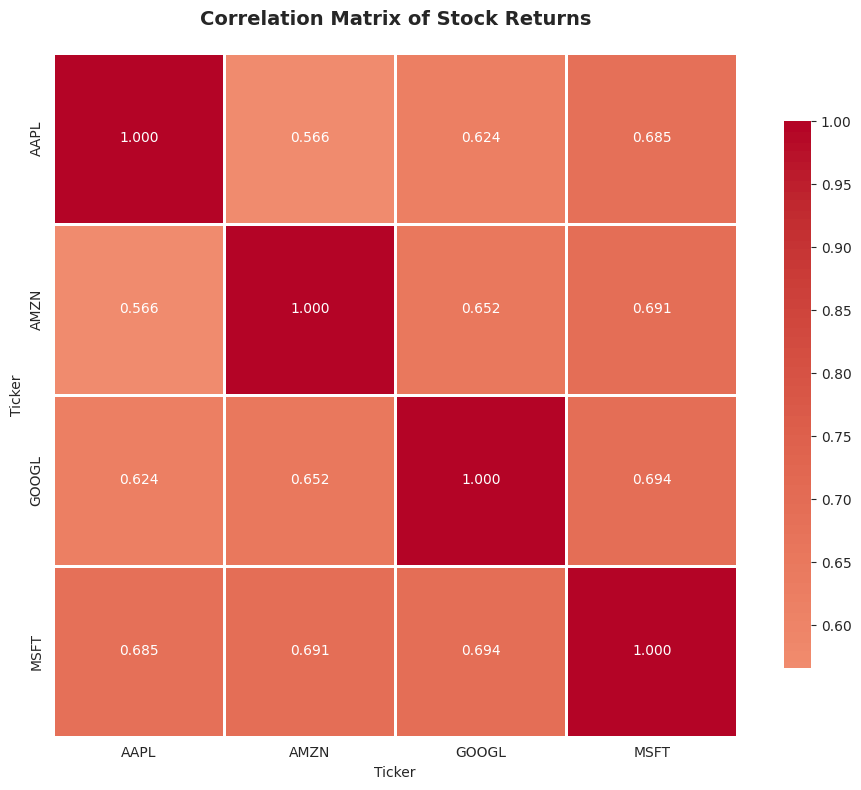


Analysis complete!


In [1]:
"""
Statistical Arbitrage Baseline Strategy
A pairs trading implementation using mean reversion of spread z-scores.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import yfinance as yf
from typing import Tuple, List, Dict
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 10)


class StatArbBaseline:
    """
    Statistical Arbitrage strategy using pairs trading and z-score signals.
    """
    
    def __init__(self, 
                 tickers: List[str],
                 start_date: str,
                 end_date: str,
                 lookback_window: int = 20,
                 entry_threshold: float = 2.0,
                 exit_threshold: float = 0.5):
        """
        Initialize the statistical arbitrage strategy.
        
        Parameters:
        -----------
        tickers : list
            List of stock tickers to analyze
        start_date : str
            Start date for data retrieval (YYYY-MM-DD)
        end_date : str
            End date for data retrieval (YYYY-MM-DD)
        lookback_window : int
            Rolling window for z-score calculation
        entry_threshold : float
            Z-score threshold for entering positions
        exit_threshold : float
            Z-score threshold for exiting positions
        """
        self.tickers = tickers
        self.start_date = start_date
        self.end_date = end_date
        self.lookback_window = lookback_window
        self.entry_threshold = entry_threshold
        self.exit_threshold = exit_threshold
        
        self.prices = None
        self.returns = None
        self.correlation_matrix = None
        self.best_pair = None
        self.backtest_results = None
        
    def load_data(self) -> pd.DataFrame:
        """
        Load price data from Yahoo Finance.
        
        Returns:
        --------
        pd.DataFrame : Adjusted close prices for all tickers
        """
        print(f"Loading data for {len(self.tickers)} tickers...")
        
        # Download data with auto_adjust to flatten the structure
        data = yf.download(
            self.tickers, 
            start=self.start_date, 
            end=self.end_date,
            auto_adjust=True,  # This returns adjusted prices as 'Close'
            progress=False
        )
        
        # Check if data is empty
        if data.empty:
            raise ValueError("No data returned from yfinance. Check your tickers and date range.")
        
        print(f"Downloaded data shape: {data.shape}")
        
        # With auto_adjust=True, adjusted close is in 'Close' column
        if isinstance(data.columns, pd.MultiIndex):
            # Multiple tickers
            if 'Close' in data.columns.get_level_values(0):
                self.prices = data['Close']
            else:
                print(f"Available columns: {data.columns.get_level_values(0).unique().tolist()}")
                raise ValueError("Couldn't find 'Close' in downloaded data")
        else:
            # Single ticker
            if 'Close' in data.columns:
                self.prices = data[['Close']].copy()
                self.prices.columns = self.tickers
            else:
                print(f"Available columns: {data.columns.tolist()}")
                raise ValueError("Couldn't find 'Close' in downloaded data")
        
        # Drop any NaN values
        self.prices = self.prices.dropna()
        
        if self.prices.empty:
            raise ValueError("All data was NaN after cleaning. Check your date range and tickers.")
        
        print(f"Loaded {len(self.prices)} days of data")
        print(f"Date range: {self.prices.index[0].date()} to {self.prices.index[-1].date()}")
        print(f"Tickers: {self.prices.columns.tolist()}")
        
        return self.prices
    
    def compute_returns(self) -> pd.DataFrame:
        """
        Compute daily log returns.
        
        Returns:
        --------
        pd.DataFrame : Daily log returns
        """
        self.returns = np.log(self.prices / self.prices.shift(1)).dropna()
        return self.returns
    
    def analyze_correlations(self) -> pd.DataFrame:
        """
        Compute correlation matrix of returns.
        
        Returns:
        --------
        pd.DataFrame : Correlation matrix
        """
        self.correlation_matrix = self.returns.corr()
        return self.correlation_matrix
    
    def find_best_pair(self) -> Tuple[str, str, float]:
        """
        Find the most correlated pair of stocks.
        
        Returns:
        --------
        tuple : (stock1, stock2, correlation)
        """
        # Create a copy and set diagonal to NaN to avoid self-correlation
        corr_copy = self.correlation_matrix.copy()
        np.fill_diagonal(corr_copy.values, np.nan)
        
        # Find maximum correlation
        max_corr = corr_copy.max().max()
        
        # Find the pair with maximum correlation
        for i in range(len(corr_copy)):
            for j in range(len(corr_copy)):
                if corr_copy.iloc[i, j] == max_corr:
                    stock1 = corr_copy.index[i]
                    stock2 = corr_copy.columns[j]
                    self.best_pair = (stock1, stock2, max_corr)
                    return self.best_pair
    
    def compute_spread(self, stock1: str, stock2: str) -> pd.Series:
        """
        Compute the spread as difference in log prices.
        
        Parameters:
        -----------
        stock1 : str
            First stock ticker
        stock2 : str
            Second stock ticker
            
        Returns:
        --------
        pd.Series : Spread time series
        """
        log_price1 = np.log(self.prices[stock1])
        log_price2 = np.log(self.prices[stock2])
        spread = log_price1 - log_price2
        return spread
    
    def compute_zscore(self, spread: pd.Series) -> pd.Series:
        """
        Compute rolling z-score of the spread.
        
        Parameters:
        -----------
        spread : pd.Series
            Spread time series
            
        Returns:
        --------
        pd.Series : Z-score time series
        """
        rolling_mean = spread.rolling(window=self.lookback_window).mean()
        rolling_std = spread.rolling(window=self.lookback_window).std()
        zscore = (spread - rolling_mean) / rolling_std
        return zscore
    
    def generate_signals(self, zscore: pd.Series) -> pd.Series:
        """
        Generate trading signals based on z-score.
        
        Trading Rules:
        - Go LONG spread when z-score < -entry_threshold
        - Go SHORT spread when z-score > entry_threshold
        - EXIT when |z-score| < exit_threshold
        
        Parameters:
        -----------
        zscore : pd.Series
            Z-score time series
            
        Returns:
        --------
        pd.Series : Position signals (1 = long, -1 = short, 0 = no position)
        """
        signals = pd.Series(index=zscore.index, data=0)
        position = 0
        
        for i in range(len(zscore)):
            z = zscore.iloc[i]
            
            if np.isnan(z):
                signals.iloc[i] = 0
                continue
            
            # Entry signals
            if z < -self.entry_threshold and position == 0:
                position = 1  # Long spread
            elif z > self.entry_threshold and position == 0:
                position = -1  # Short spread
            
            # Exit signals
            elif abs(z) < self.exit_threshold and position != 0:
                position = 0
            
            signals.iloc[i] = position
        
        return signals
    
    def backtest(self, stock1: str, stock2: str) -> Dict:
        """
        Backtest the pairs trading strategy.
        
        Parameters:
        -----------
        stock1 : str
            First stock ticker
        stock2 : str
            Second stock ticker
            
        Returns:
        --------
        dict : Backtest results including equity curve, trades, and metrics
        """
        print(f"\n{'='*60}")
        print(f"Backtesting pair: {stock1} vs {stock2}")
        print(f"{'='*60}")
        
        # Compute spread and z-score
        spread = self.compute_spread(stock1, stock2)
        zscore = self.compute_zscore(spread)
        
        # Generate signals
        signals = self.generate_signals(zscore)
        
        # Compute spread returns (change in spread)
        spread_returns = spread.diff()
        
        # Compute strategy returns
        # Long spread: profit when spread increases
        # Short spread: profit when spread decreases
        strategy_returns = signals.shift(1) * spread_returns
        strategy_returns = strategy_returns.fillna(0)
        
        # Compute cumulative returns
        cumulative_returns = (1 + strategy_returns).cumprod()
        
        # Identify trades
        position_changes = signals.diff()
        entries = position_changes[position_changes != 0].index
        
        # Calculate performance metrics
        total_return = cumulative_returns.iloc[-1] - 1
        annual_return = (1 + total_return) ** (252 / len(strategy_returns)) - 1
        
        # Sharpe ratio (annualized)
        sharpe_ratio = np.sqrt(252) * strategy_returns.mean() / strategy_returns.std() if strategy_returns.std() != 0 else 0
        
        # Maximum drawdown
        rolling_max = cumulative_returns.expanding().max()
        drawdown = (cumulative_returns - rolling_max) / rolling_max
        max_drawdown = drawdown.min()
        
        # Win rate
        wins = (strategy_returns > 0).sum()
        losses = (strategy_returns < 0).sum()
        win_rate = wins / (wins + losses) if (wins + losses) > 0 else 0
        
        # Number of trades
        num_trades = len(entries)
        
        results = {
            'spread': spread,
            'zscore': zscore,
            'signals': signals,
            'strategy_returns': strategy_returns,
            'cumulative_returns': cumulative_returns,
            'entries': entries,
            'total_return': total_return,
            'annual_return': annual_return,
            'sharpe_ratio': sharpe_ratio,
            'max_drawdown': max_drawdown,
            'win_rate': win_rate,
            'num_trades': num_trades
        }
        
        self.backtest_results = results
        
        # Print summary
        print(f"\nPerformance Summary:")
        print(f"-" * 60)
        print(f"Total Return:        {total_return:>10.2%}")
        print(f"Annualized Return:   {annual_return:>10.2%}")
        print(f"Sharpe Ratio:        {sharpe_ratio:>10.2f}")
        print(f"Max Drawdown:        {max_drawdown:>10.2%}")
        print(f"Win Rate:            {win_rate:>10.2%}")
        print(f"Number of Trades:    {num_trades:>10}")
        print(f"-" * 60)
        
        return results
    
    def plot_results(self):
        """
        Create comprehensive visualization of backtest results.
        """
        if self.backtest_results is None:
            print("No backtest results to plot. Run backtest() first.")
            return
        
        results = self.backtest_results
        stock1, stock2, corr = self.best_pair
        
        fig, axes = plt.subplots(4, 1, figsize=(14, 12))
        
        # Plot 1: Price time series
        ax1 = axes[0]
        norm_prices = self.prices[[stock1, stock2]] / self.prices[[stock1, stock2]].iloc[0]
        norm_prices.plot(ax=ax1, linewidth=2)
        ax1.set_title(f'Normalized Price Time Series: {stock1} vs {stock2}', 
                     fontsize=14, fontweight='bold')
        ax1.set_ylabel('Normalized Price')
        ax1.legend(loc='best')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Spread and Z-score
        ax2 = axes[1]
        ax2_twin = ax2.twinx()
        
        results['spread'].plot(ax=ax2, color='blue', linewidth=1.5, label='Spread')
        ax2.set_ylabel('Spread (Log Price Difference)', color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')
        
        results['zscore'].plot(ax=ax2_twin, color='red', linewidth=1.5, label='Z-Score')
        ax2_twin.axhline(y=self.entry_threshold, color='green', linestyle='--', 
                        alpha=0.7, label=f'Entry Threshold (±{self.entry_threshold})')
        ax2_twin.axhline(y=-self.entry_threshold, color='green', linestyle='--', alpha=0.7)
        ax2_twin.axhline(y=self.exit_threshold, color='orange', linestyle='--', 
                        alpha=0.7, label=f'Exit Threshold (±{self.exit_threshold})')
        ax2_twin.axhline(y=-self.exit_threshold, color='orange', linestyle='--', alpha=0.7)
        ax2_twin.axhline(y=0, color='black', linestyle='-', alpha=0.3)
        ax2_twin.set_ylabel('Z-Score', color='red')
        ax2_twin.tick_params(axis='y', labelcolor='red')
        
        ax2.set_title('Spread and Z-Score with Trading Thresholds', 
                     fontsize=14, fontweight='bold')
        ax2_twin.legend(loc='upper right')
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Z-score with trade markers
        ax3 = axes[2]
        results['zscore'].plot(ax=ax3, color='purple', linewidth=1.5)
        
        # Mark entry points
        for entry_date in results['entries']:
            if entry_date in results['signals'].index:
                signal = results['signals'][entry_date]
                z_value = results['zscore'][entry_date]
                if signal == 1:  # Long entry
                    ax3.scatter(entry_date, z_value, color='green', s=100, 
                              marker='^', zorder=5, label='Long Entry' if entry_date == results['entries'][0] else '')
                elif signal == -1:  # Short entry
                    ax3.scatter(entry_date, z_value, color='red', s=100, 
                              marker='v', zorder=5, label='Short Entry' if entry_date == results['entries'][0] else '')
                elif signal == 0:  # Exit
                    ax3.scatter(entry_date, z_value, color='orange', s=100, 
                              marker='x', zorder=5, label='Exit' if entry_date == results['entries'][0] else '')
        
        ax3.axhline(y=self.entry_threshold, color='green', linestyle='--', alpha=0.5)
        ax3.axhline(y=-self.entry_threshold, color='green', linestyle='--', alpha=0.5)
        ax3.axhline(y=self.exit_threshold, color='orange', linestyle='--', alpha=0.5)
        ax3.axhline(y=-self.exit_threshold, color='orange', linestyle='--', alpha=0.5)
        ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
        
        ax3.set_title('Z-Score with Trade Signals', fontsize=14, fontweight='bold')
        ax3.set_ylabel('Z-Score')
        
        # Remove duplicate labels in legend
        handles, labels = ax3.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax3.legend(by_label.values(), by_label.keys(), loc='best')
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Equity curve
        ax4 = axes[3]
        results['cumulative_returns'].plot(ax=ax4, color='darkblue', linewidth=2)
        ax4.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Break-even')
        ax4.set_title('Equity Curve (Cumulative Returns)', fontsize=14, fontweight='bold')
        ax4.set_ylabel('Cumulative Return')
        ax4.set_xlabel('Date')
        ax4.legend(loc='best')
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Additional plot: Correlation heatmap
        self.plot_correlation_heatmap()
    
    def plot_correlation_heatmap(self):
        """
        Plot correlation heatmap of stock returns.
        """
        plt.figure(figsize=(10, 8))
        sns.heatmap(self.correlation_matrix, annot=True, fmt='.3f', 
                   cmap='coolwarm', center=0, square=True,
                   linewidths=1, cbar_kws={"shrink": 0.8})
        plt.title('Correlation Matrix of Stock Returns', 
                 fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()
    
    def run_full_analysis(self):
        """
        Run complete statistical arbitrage analysis pipeline.
        """
        print("\n" + "="*60)
        print("STATISTICAL ARBITRAGE BASELINE ANALYSIS")
        print("="*60)
        
        # Step 1: Load data
        self.load_data()
        
        # Step 2: Compute returns
        self.compute_returns()
        
        # Step 3: Analyze correlations
        self.analyze_correlations()
        print(f"\nCorrelation Matrix:")
        print(self.correlation_matrix)
        
        # Step 4: Find best pair
        stock1, stock2, corr = self.find_best_pair()
        print(f"\nMost correlated pair: {stock1} & {stock2}")
        print(f"Correlation: {corr:.4f}")
        
        # Step 5: Backtest
        self.backtest(stock1, stock2)
        
        # Step 6: Plot results
        self.plot_results()


def main():
    """
    Main execution function.
    """
    # Configuration
    TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
    START_DATE = '2022-01-01'
    END_DATE = '2024-12-31'
    LOOKBACK_WINDOW = 20
    ENTRY_THRESHOLD = 2.0
    EXIT_THRESHOLD = 0.5
    
    # Initialize strategy
    strategy = StatArbBaseline(
        tickers=TICKERS,
        start_date=START_DATE,
        end_date=END_DATE,
        lookback_window=LOOKBACK_WINDOW,
        entry_threshold=ENTRY_THRESHOLD,
        exit_threshold=EXIT_THRESHOLD
    )
    
    # Run analysis
    strategy.run_full_analysis()
    
    print("\n" + "="*60)
    print("Analysis complete!")
    print("="*60)


if __name__ == "__main__":
    main()
